In [ ]:
 # Exponential mixture (2 components) with interactive sliders
# f(x) = w * λ1 * exp(-λ1 x) + (1 - w) * λ2 * exp(-λ2 x)

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def plot_mixture(w: float, lam1: float, lam2: float):
    # Pick an x-range that adapts to the slower-decaying component
    lam_min = max(min(lam1, lam2), 1e-6)
    x_max = 10.0 / lam_min  # ~10 e-folds of the slowest component
    x = np.linspace(0.0, 5, 800)

    # Components (each is a proper exponential PDF on [0, ∞))
    f1 = lam1 * np.exp(-lam1 * x)
    f2 = lam2 * np.exp(-lam2 * x)

    # Mixture
    f = w * f1 + (1.0 - w) * f2

    # Plot
    plt.figure(figsize=(7.5, 4.5))
    plt.plot(x, f1, label=r"Component 1: $\lambda_1$ = %.3g" % lam1, linewidth=2)
    plt.plot(x, f2, label=r"Component 2: $\lambda_2$ = %.3g" % lam2, linewidth=2)
    plt.plot(x, f,  label=r"Mixture: $w\,\lambda_1 e^{-\lambda_1 x} + (1-w)\,\lambda_2 e^{-\lambda_2 x}$", linewidth=2)

    plt.xlabel("x")
    plt.ylabel("density")
    plt.title(r"Two-Component Exponential Mixture  (weight $w$ = %.2f)" % w)
    plt.grid(True, alpha=0.3)
    plt.ylim(1e-3, 2.5)
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Sliders:
# - w in [0,1]
# - λ1, λ2 on a log slider for convenient exploration over orders of magnitude
w_slider = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.01, readout_format=".2f", description="w")
lam1_slider = widgets.FloatLogSlider(value=1.0, base=10, min=-2, max=2, step=0.01, description="λ1")
lam2_slider = widgets.FloatLogSlider(value=0.2, base=10, min=-2, max=2, step=0.01, description="λ2")

interact(plot_mixture, w=w_slider, lam1=lam1_slider, lam2=lam2_slider);


interactive(children=(FloatSlider(value=0.5, description='w', max=1.0, step=0.01), FloatLogSlider(value=1.0, d…

# Background Flexibility Proof of Concept

In [2]:
import sys
sys.path.append("/project01/ndcms/atownse2/ExponentialMixtureModel")

import ROOT
import emm

import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Get data
data_tree = emm.get_data(sort_and_index=True, tree=True)

x = ROOT.RooRealVar("x", "Diphoton Mass [GeV]", 500, 4000)
# index=ROOT.RooRealVar("index", "index", 0, 0, 1e6)

data = ROOT.RooDataSet("mgg", "mgg", ROOT.RooArgSet(x), ROOT.RooFit.Import(data_tree))

Loaded 5036 diphoton invariant masses from data.


[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_3_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const o

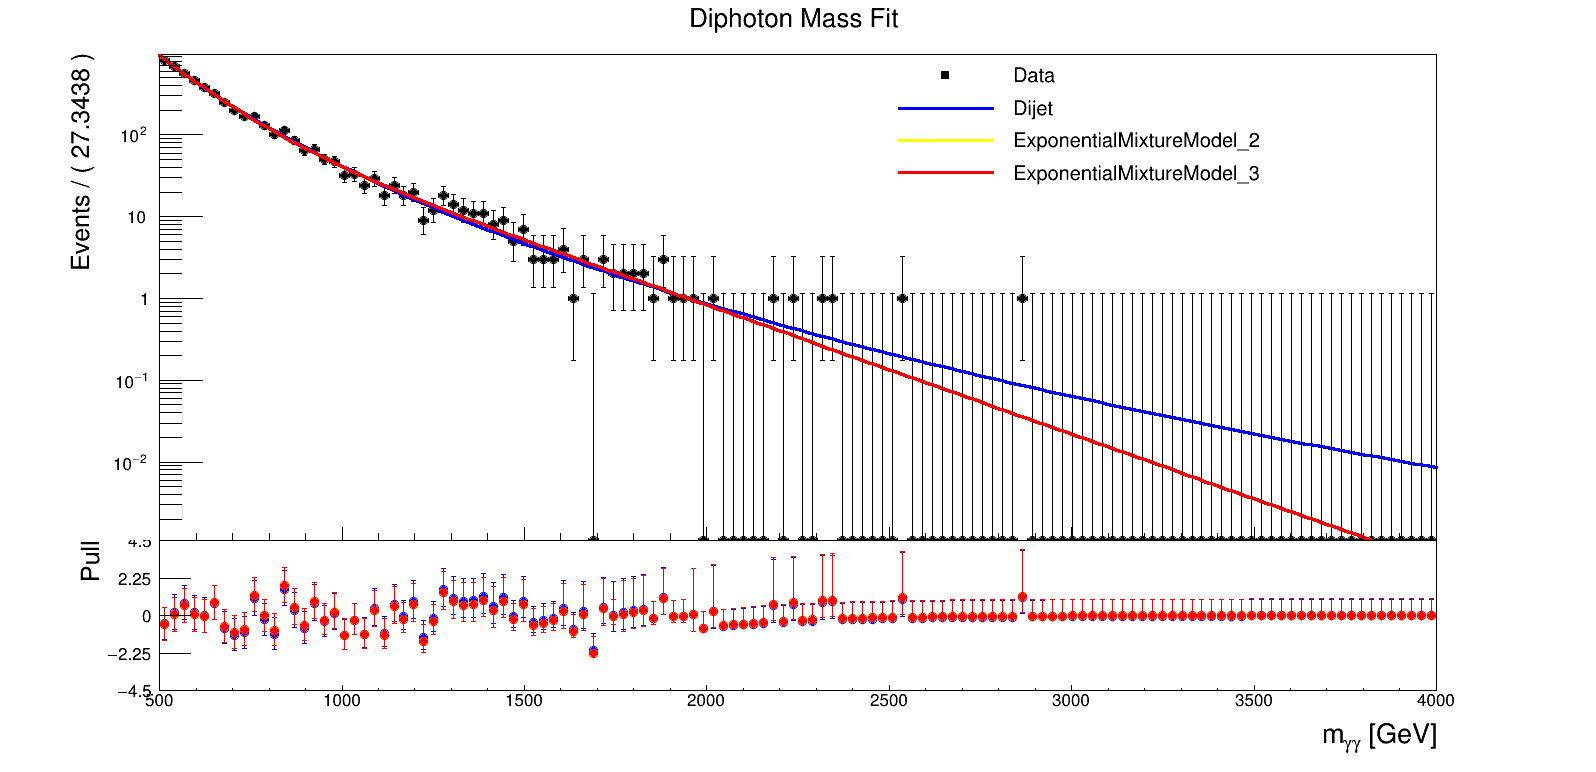

In [15]:
# Plot fits of varying complexity to the signal + background data
models = [emm.Dijet(x)]
models += [emm.ExponentialMixtureModel(x, k, data_mean=data.mean(x)) for k in range(2, 4)]
model_labels = [m.name for m in models]
for m in models:
    m.pdf.fitTo(data, PrintLevel=-1)

emm.plot_fits(data, x, models, model_labels, logx=False)

Data entries (with tail events): 5040
[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_3_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::

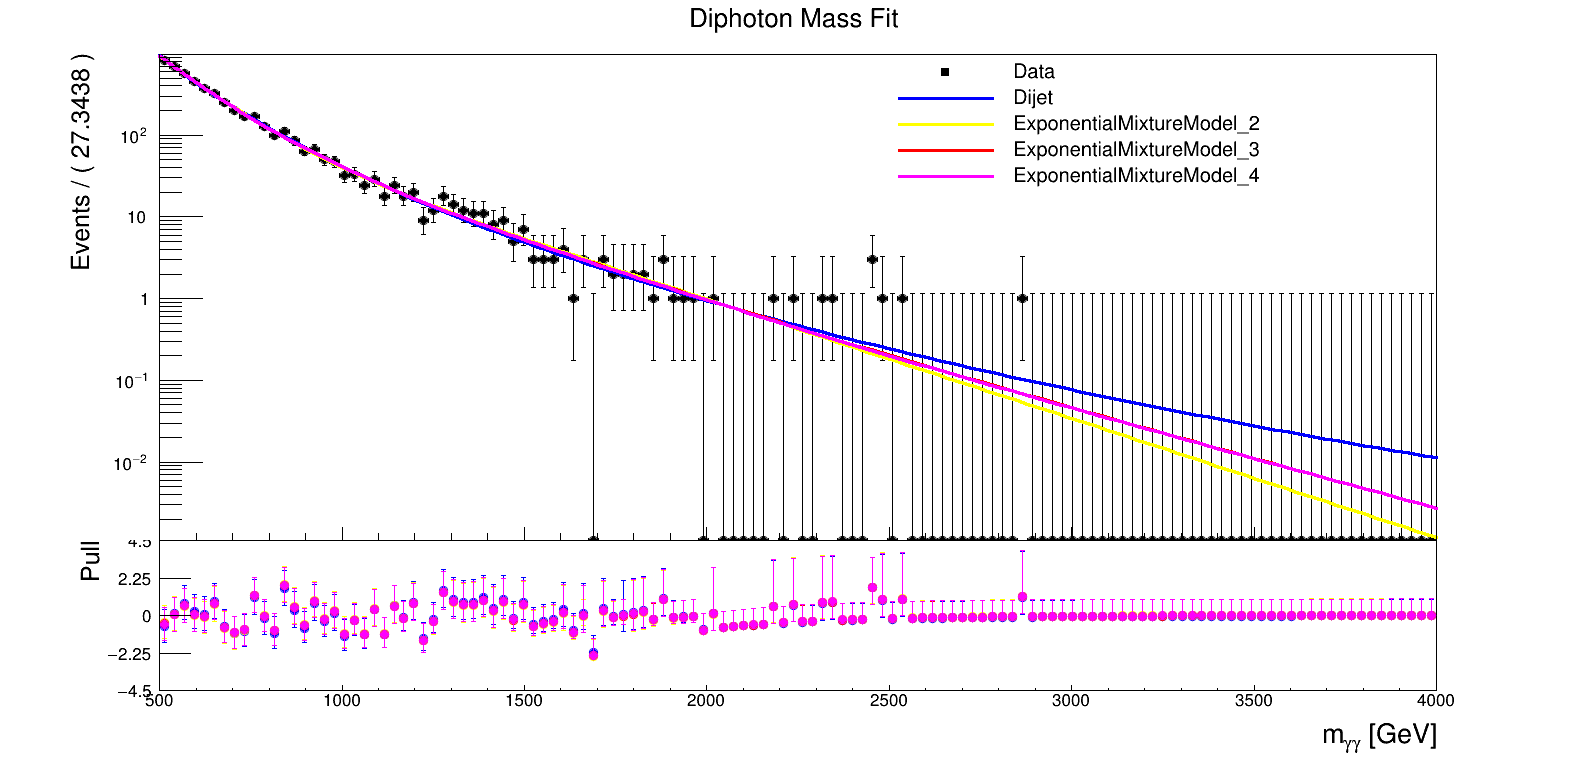

In [27]:
# Add signal to tail
m = 2500
s = 40
n = 4

data_sig = data.Clone()
vals_to_add = np.random.normal(m, s, size=n)
for val in vals_to_add:
    x.setVal(val)
    # index.setVal(data_sig.numEntries())
    data_sig.add(ROOT.RooArgSet(x))

print(f"Data entries (with tail events): {data_sig.numEntries()}")

# Plot fits of varying complexity to the signal + background data
models = [emm.Dijet(x)]
models += [emm.ExponentialMixtureModel(x, k, data_mean=data_sig.mean(x)) for k in [2, 3, 4]]
model_labels = [m.name for m in models]
for m in models:
    m.pdf.fitTo(data_sig, PrintLevel=-1)
emm.plot_fits(data_sig, x, models, model_labels, logx=False)

[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_3_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const o

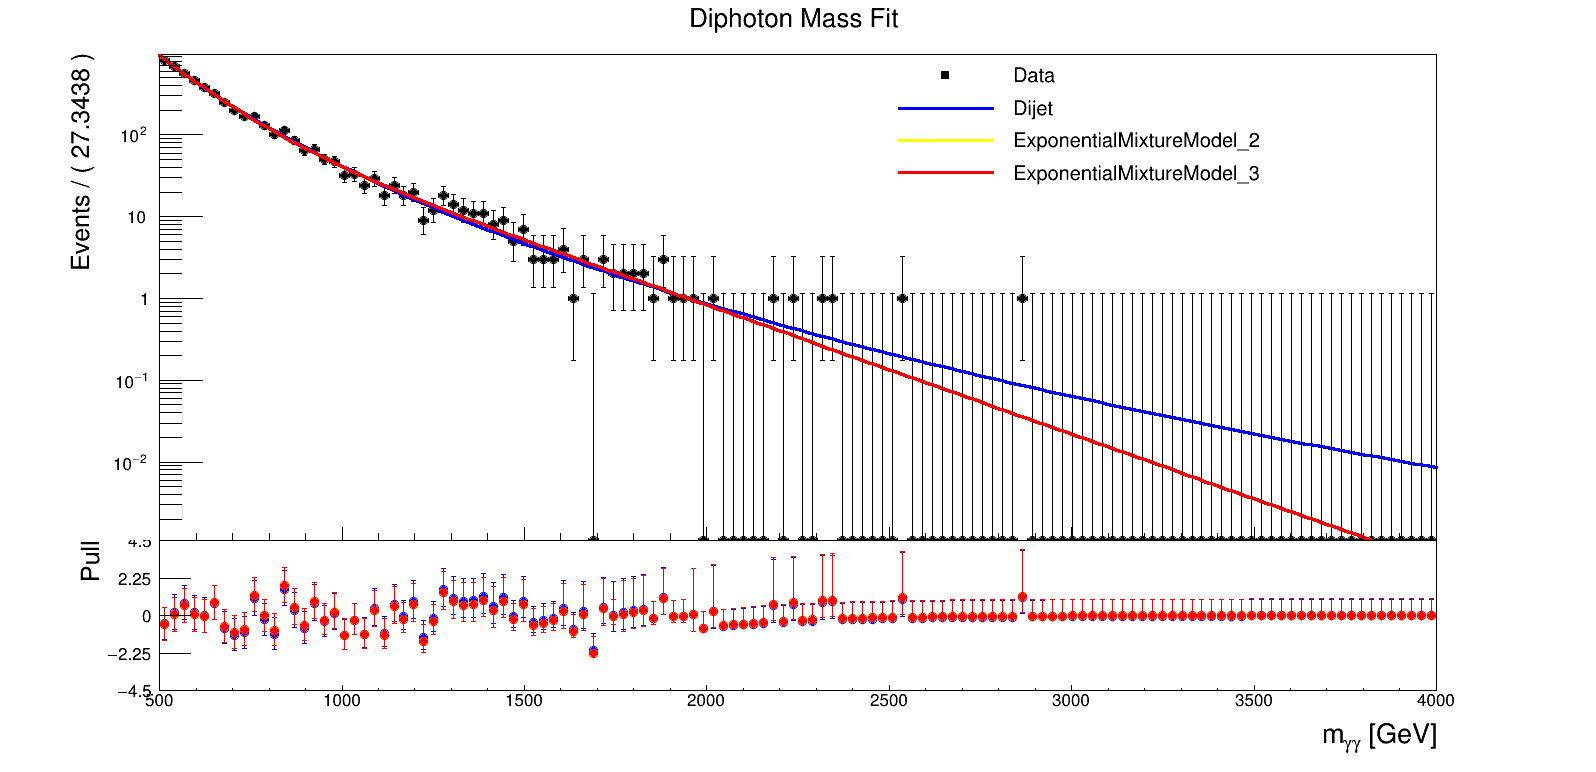

In [13]:
# Plot fits of varying complexity to the signal + background data
models = [emm.Dijet(x)]
models += [emm.ExponentialMixtureModel(x, k, data_mean=data.mean(x)) for k in range(2, 4)]
model_labels = [m.name for m in models]
for m in models:
    m.pdf.fitTo(data, PrintLevel=-1)

emm.plot_fits(data, x, models, model_labels, logx=False)

[#1] INFO:NumericIntegration -- RooRealIntegral::init(Dijet_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_2_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:NumericIntegration -- RooRealIntegral::init(ExponentialMixtureModel_3_Int[x]) using numeric integrator RooRombergIntegrator to calculate Int(x)
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const o

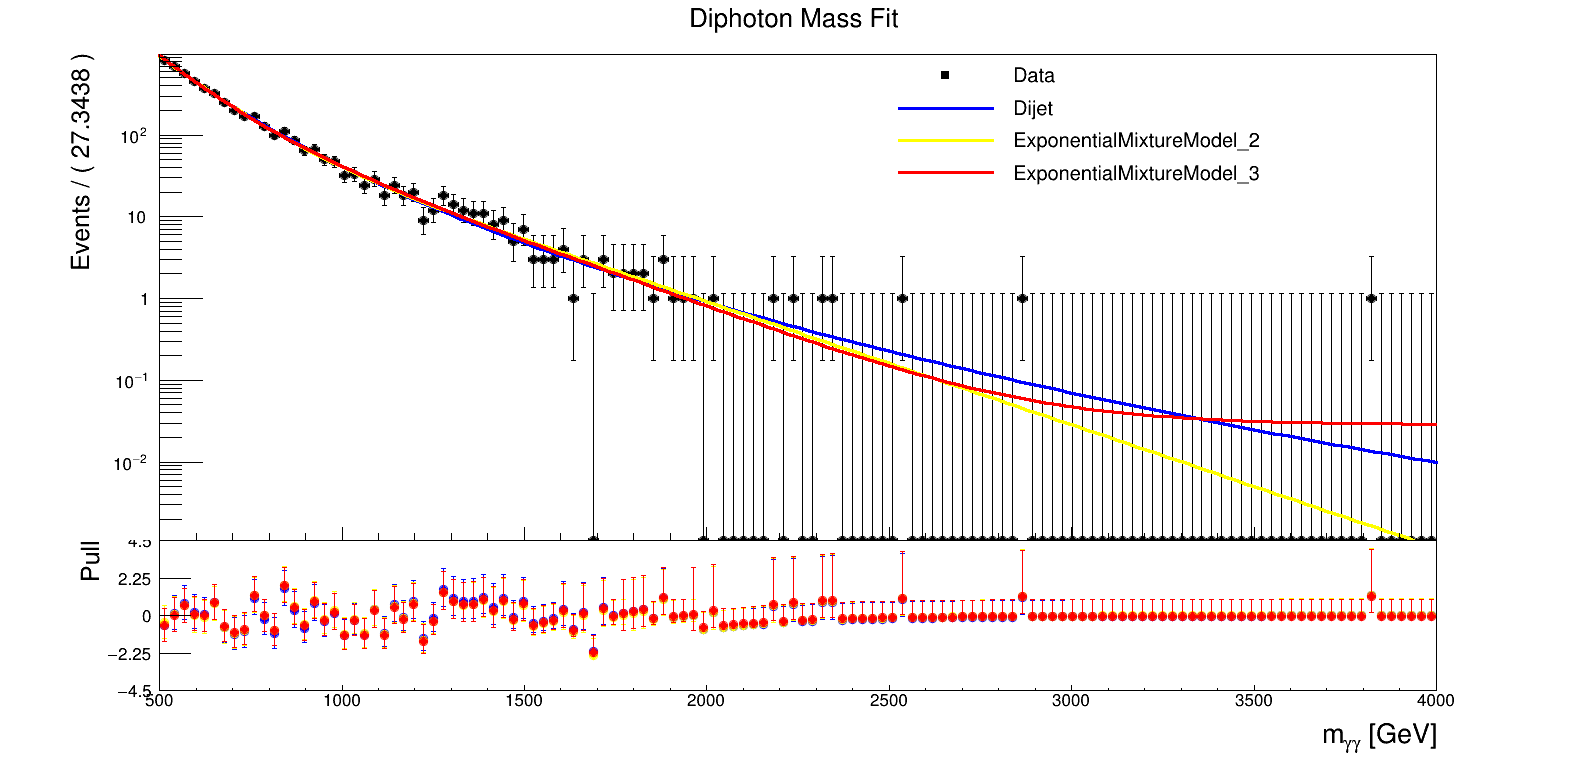